In [30]:
# Bart Post-COVID Recovery Analysis

#**Question** Which BART stations recovered to pre-pandemic ridership levels, if at all? 

# **Data:** BART monthly origin-destination matrices, 2018–2025, 
# downloaded from bart.gov. Each file contains four tabs (Total Trips, 
# Average Weekday, Average Saturday, Average Sunday) and is structured 
# as a wide matrix with origin stations across columns and destination 
# stations down rows.


# **Notebook 1 of N:** Initial data exploration — understanding what 
# BART actually publishes before doing any analysis.

In [31]:
import pandas as pd
import os

data_path = '../Data/raw'
print(os.listdir(data_path))

#rename
for folder_name in os.listdir(data_path):
    if folder_name == '.DS_Store':
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")


['.DS_Store', 'ridership_2018', 'ridership_2020', 'ridership_2021', 'ridership_2019', 'ridership_2023', 'ridership_2024', 'ridership_2025', 'ridership_2022', 'bart_abbs.xls']


In [32]:
#rename
for folder_name in os.listdir(data_path):
    if folder_name == ".DS_Store":
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")

In [33]:
year_2024_p = "../Data/raw/ridership_2024"

for folder_name in sorted(os.listdir(year_2024_p)):
    if folder_name != ".DS_Store":
        print(folder_name)


Ridership_202401.xlsx
Ridership_202402.xlsx
Ridership_202403.xlsx
Ridership_202404.xlsx
Ridership_202405.xlsx
Ridership_202406.xlsx
Ridership_202407.xlsx
Ridership_202408.xlsx
Ridership_202409.xlsx
Ridership_202410.xlsx
Ridership_202411.xlsx
Ridership_202412.xlsx


In [34]:
import pandas as pd

file_path = os.path.join(year_2024_p, "Ridership_202401.xlsx")

xl = pd.ExcelFile(file_path)

print(xl.sheet_names)

['Total Trips', 'Average Weekday', 'Average Saturday', 'Average Sunday']


In [35]:
# Step 3: Open the Average Weekday tab

# For recovery analysis, I'll focus on **Average Weekday** ridership 
# since that's the metric most affected by post-COVID work-from-home 
# patterns. Weekend ridership tells a different story.

# Each tab is structured as a wide origin-destination matrix with 
# origin stations across the columns and destination stations down 
# the rows. Each cell is the average number of trips between those 
# two stations on a typical weekday that month.

In [36]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.428571,69.666667,58.428571,33.571429,222.714286,47.095238,75.761905,62.190476,76.142857,...,35.857143,11.47619,4.190476,7.809524,13.333333,3.952381,10.47619,5.238095,6,2054.857143


In [37]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.428571,69.666667,58.428571,33.571429,222.714286,47.095238,75.761905,62.190476,76.142857,...,35.857143,11.47619,4.190476,7.809524,13.333333,3.952381,10.47619,5.238095,6,2054.857143


In [38]:
weekday_jan_2024 = pd.read_excel(file_path,skiprows=4)
print(weekday_jan_2024)

   Exit Station Two-Letter Code     RM     EN     EP     NB      BK     AS  \
0                            RM    425   1800   1556    870    5754   1216   
1                            EN   1822    545   1712   1258    9138   1528   
2                            EP   1651   1528    219    884    7677   1167   
3                            NB    884   1056    878    266    2015    648   
4                            BK   6545   9449   7961   2310    1083   3814   
5                            AS   1189   1484   1260    815    3710    297   
6                            MA   2306   2615   1423    987    3854   1073   
7                            19   1700   3598   2307   2055    5049   2138   
8                            12   1993   4282   2526   1897    5024   2019   
9                            LM    521    920    629    498    2225    636   
10                           FV   1358   1586    679    753    3026   1362   
11                           CL   1054    872    247    338    1

In [39]:
!pip install xlrd

In [40]:
stations_p = "../Data/raw/bart_abbs.xls"
stations = pd.read_excel(stations_p, usecols=['Two-Letter Station Code', 'Station Name'])
stations.head()

stations

,Two-Letter Station Code,Station Name
0,RM,Richmond
1,EN,El Cerrito Del Norte
2,EP,El Cerrito Plaza
3,NB,North Berkeley
4,BK,Berkeley
5,AS,Ashby
6,MA,MacArthur
7,19,19th Street Oakland
8,12,12th Street / Oakland City Center
9,LM,Lake Merritt


In [41]:
weekday_jan_2024_long = pd.melt(weekday_jan_2024, id_vars = "Exit Station Two-Letter Code", var_name = "origin", value_name = "trips" )

# Data Above is very long with several "phantom trips"
# Phantom trips can be identified with the same origin and same destination
# Exit Station Two Letter Code needs to be renamed to Origin after further inspection and 

In [42]:

weekday_jan_2024_long[
    (weekday_jan_2024_long["Exit Station Two-Letter Code"] == "EM") &
    (weekday_jan_2024_long["origin"] == "WC")
]

,Exit Station Two-Letter Code,origin,trips
1045,EM,WC,12852


In [43]:
weekday_jan_2024_long = weekday_jan_2024_long.rename(
    columns={"Exit Station Two-Letter Code": "destination"})
weekday_jan_2024_long.head()

,destination,origin,trips
0,RM,RM,425
1,EN,RM,1822
2,EP,RM,1651
3,NB,RM,884
4,BK,RM,6545


In [44]:
weekday_jan_2024_long = weekday_jan_2024_long[["origin", "destination", "trips"]]
weekday_jan_2024_long.head()


,origin,destination,trips
0,RM,RM,425
1,RM,EN,1822
2,RM,EP,1651
3,RM,NB,884
4,RM,BK,6545


###
#Cleaning up Filters like "Grand Total" and "Unamed"


In [45]:
weekday_jan_2024_long["destination"].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', '19', '12', 'LM', 'FV',
       'CL', 'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF',
       'OR', 'RR', 'OW', 'EM', 'MT', 'PL', 'CC', '16', '24', 'GP', 'BP',
       'DC', 'CM', 'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD',
       'OA', 'WS', 'PC', 'AN', 'ML', 'BE', 'Grand Total'], dtype=object)

In [46]:
weekday_jan_2024_clean = weekday_jan_2024_long[
    (weekday_jan_2024_long['origin'] != weekday_jan_2024_long['destination']) &
    (weekday_jan_2024_long['destination'] != 'Grand Total') &
    (weekday_jan_2024_long['origin'] != 'Unnamed: 51')
].copy()

weekday_jan_2024_clean.shape

(2450, 3)

###
# Adding a month column so each row carries its own date. 
# Once we stack data from all 96 files into one DataFrame, this column will let us filter, 
# group, and compare across months — without it, 
# all the rows would look identical regardless of which month they came from.

In [47]:
weekday_jan_2024_clean["month"] = "2024-01"

In [48]:
### Next step: build a reusable function

# After exploring how one BART monthly file is structured, the next step 
# is to wrap the entire cleaning process into a single function. That way, 
# applying the same recipe to all 96 monthly files becomes a one-line call 
# inside a loop.

In [49]:
def find_header_row(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    for i in range(len(raw)):
        cell = raw.iloc[i, 0]
        if isinstance(cell, str) and 'Exit Station' in cell:
            return i
    return None 
    

In [50]:
def load_and_clean_month(file_path):

    xl = pd.ExcelFile(file_path)
    filename = os.path.basename(file_path)
    
    weekday_sheet = None
    for sheet in xl.sheet_names:
        if "Weekday" in sheet:
            weekday_sheet = sheet
            break

    if "OD" in weekday_sheet:
        skip = 1
    # These 2 files (out of 96) have one fewer header row than their siblings,
    # so the station-code row is at index 3 instead of 4. skiprows=3 fixes them.
    elif filename in ["Ridership_202410.xlsx" , "Ridership_202508.xlsx"]:
        skip = 3
    else:
        skip = 4
           
    ridership_df = pd.read_excel(file_path, sheet_name= weekday_sheet, skiprows = skip)
    ridership_df = pd.melt(ridership_df, id_vars=ridership_df.columns[0], var_name="origin", value_name="trips")
    ridership_df = ridership_df.rename(columns={ridership_df.columns[0]: "destination"})
    ridership_df = ridership_df[["origin", "destination", "trips"]]
    ridership_df = ridership_df[
            (ridership_df["origin"] != ridership_df["destination"]) &
        (ridership_df["destination"] != "Grand Total") &
        (ridership_df["origin"] != "Unnamed: 51")].copy()
    ridership_df["month"] = f"{filename[10:14]}-{filename[14:16]}"
    return ridership_df


In [51]:
test = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202401.xlsx")
test.shape

(2450, 4)

#sanity check

In [52]:
test_march = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202403.xlsx")
test_march.shape
test_march.head()

,origin,destination,trips,month
1,RM,EN,70.476190,2024-03
2,RM,EP,64.666667,2024-03
3,RM,NB,35.666667,2024-03
4,RM,BK,283.333333,2024-03
5,RM,AS,44.666667,2024-03


### Next Step: Creating a Loop to go through the files BART has Published

In [53]:
all_months = []

for year_folder in sorted(os.listdir(data_path)):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    
    for filename in sorted(os.listdir(year_path)):
        if filename == ".DS_Store":
            continue

        full_path = os.path.join(year_path, filename)
        print(full_path)
        cleaned = load_and_clean_month(full_path)
        all_months.append(cleaned)

all_data = pd.concat(all_months, ignore_index=True)
all_data.shape        

    

../Data/raw/ridership_2018/Ridership_201801.xlsx
../Data/raw/ridership_2018/Ridership_201802.xlsx
../Data/raw/ridership_2018/Ridership_201803.xlsx
../Data/raw/ridership_2018/Ridership_201804.xlsx
../Data/raw/ridership_2018/Ridership_201805.xlsx
../Data/raw/ridership_2018/Ridership_201806.xlsx
../Data/raw/ridership_2018/Ridership_201807.xlsx
../Data/raw/ridership_2018/Ridership_201808.xlsx
../Data/raw/ridership_2018/Ridership_201809.xlsx
../Data/raw/ridership_2018/Ridership_201810.xlsx
../Data/raw/ridership_2018/Ridership_201811.xlsx
../Data/raw/ridership_2018/Ridership_201812.xlsx
../Data/raw/ridership_2019/Ridership_201901.xlsx
../Data/raw/ridership_2019/Ridership_201902.xlsx
../Data/raw/ridership_2019/Ridership_201903.xlsx
../Data/raw/ridership_2019/Ridership_201904.xlsx
../Data/raw/ridership_2019/Ridership_201905.xlsx
../Data/raw/ridership_2019/Ridership_201906.xlsx
../Data/raw/ridership_2019/Ridership_201907.xlsx
../Data/raw/ridership_2019/Ridership_201908.xlsx
../Data/raw/ridershi

(240920, 4)

In [54]:
all_data.shape

(240920, 4)

In [55]:
all_data['month'].value_counts().sort_index()

month
2018-01    2163
2018-02    2163
2018-03    2163
2018-04    2163
2018-05    2551
           ... 
2025-08    2450
2025-09    2450
2025-10    2450
2025-11    2450
2025-12    2450
Name: count, Length: 96, dtype: int64

In [56]:
# Are months continuous, no gaps?
print(all_data['month'].nunique())   # how many distinct months — should be 96 (or however many you actually downloaded)

96


In [57]:
all_data[
    (all_data['origin'] == 'EM') &
    (all_data['destination'] == 'WC')
].sort_values('month').head(20)

,origin,destination,trips,month
1170,EM,WC,1429.238095,2018-01
3333,EM,WC,1388.842105,2018-02
5496,EM,WC,1376.318182,2018-03
7659,EM,WC,1377.095238,2018-04
9922,EM,WC,1391.227273,2018-05
12473,EM,WC,1452.476190,2018-06
15024,EM,WC,1434.238095,2018-07
17575,EM,WC,1425.956522,2018-08
20126,EM,WC,1431.473684,2018-09
22677,EM,WC,1405.727273,2018-10


In [58]:
all_data[(all_data["origin"] == "EM") & (all_data["destination"] == "WC") & (all_data["month"] == "2024-01")]
all_data[(all_data["origin"] == "WC") & (all_data["destination"] == "EM") & (all_data["month"] == '"024-01")]

SyntaxError: unterminated string literal (detected at line 2) (2697692396.py, line 2)

In [ ]:
result = all_data.groupby('origin')['trips'].sum()
result

In [ ]:
all_data['origin'].unique()

In [ ]:
all_data['origin'].value_counts()

In [ ]:
test_2018 = pd.read_excel('../Data/raw/ridership_2018/Ridership_201801.xlsx', sheet_name='Weekday OD', skiprows=1)
test_2018.columns.tolist()

In [ ]:
# Find rows where origin is a decimal-looking value
weird = all_data[all_data['origin'] == 23.818181818181813]
weird['month'].unique()


In [ ]:
# Check the data type of each origin value
all_data['origin'].apply(type).value_counts()

In [ ]:
bad_rows = all_data[all_data['origin'].apply(type) == float]
bad_rows['month'].unique()

In [ ]:
###
# While running sanity checks on `all_data['origin'].unique()`, I 
# discovered 4,606 rows where the origin column contained float values 
# (decimals like 23.81, 75.04) instead of station codes. Investigating 
# with `.apply(type)` showed that 4,606 origin values are floats and 
# 14,630 are ints — the rest (221,782) are correctly strings.

# Filtering by data type, I traced the float-typed origins to two 
# specific months: **October 2024 and August 2025**. All other 94 
# months are clean.

# It could be that BART had a different sheet structure than their sibling files in the same year.
#The function maybe reading the wrong row as headers, causing decimals to be labled as "origins"

### Next steps
# 1. Open the 2024-10 file and check sheet names + structure
# 2. Compare to a working file from the same year (2024-01)
# 3. Update the function to handle whatever variation exists
# 4. Re-run the loop with the fix
# 5. Verify origin column is now clean

In [ ]:
def trips_by_origin(year):
    filter = all_data[all_data["month"].str.startswith(str(year))]
    result = filter.groupby("origin")["trips"].sum()
    return result.sort_values(ascending=False)

In [ ]:
all_data['origin'] = all_data['origin'].astype(str)
all_data['destination'] = all_data['destination'].astype(str)

In [ ]:
all_data['origin'].apply(type).value_counts()
all_data['origin'].nunique()

In [ ]:
all_data = all_data[all_data['origin'] != 'Exits']

In [ ]:
all_data['origin'].unique()

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format
print("2024:")
print(trips_by_origin(2024).head(10))
print("\n2019:")
print(trips_by_origin(2019).head(10))


In [63]:
aggregated_df = all_data.groupby("month")["trips"].sum().reset_index()
aggregated_df

,month,trips
0,2018-01,1.579449e+06
1,2018-02,1.654177e+06
2,2018-03,1.633733e+06
3,2018-04,1.650549e+06
4,2018-05,1.665588e+06
...,...,...
91,2025-08,1.848979e+05
92,2025-09,1.929771e+05
93,2025-10,1.965549e+05
94,2025-11,1.843970e+05


<Axes: title={'center': 'BART System-Wide Average Weekday Ridership (2018-2025)'}, xlabel='month'>

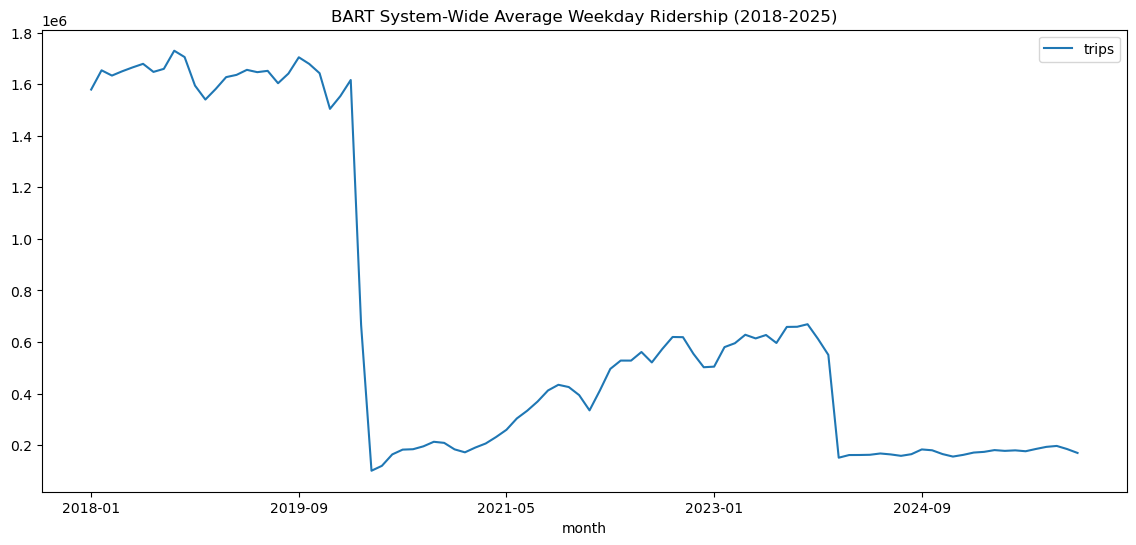

In [64]:
aggregated_df.plot(x = "month", y = "trips", figsize = (14,6), title = "BART System-Wide Average Weekday Ridership (2018-2025)")

In [ ]:
### noticed a drop from 2023 to 2024.

In [65]:
aggregated_df = [aggregated_df['month'].between('2023-10', '2024-04')]